In [1]:
# ==============================
# ELECTRIC UAV - DESIGN INPUTS
# ==============================

# Aircraft geometry and mass
mass = 12.0              # kg
wingspan = 3.0           # m
wing_area = 1.2          # m^2

# Flight conditions
cruise_speed = 22.0      # m/s
air_density = 1.225      # kg/m^3
gravity = 9.81           # m/s^2

# Aerodynamic parameters
cd0 = 0.025
oswald_efficiency = 0.80

# Propulsion efficiencies
eta_inverter = 0.95
eta_motor = 0.95
eta_propeller = 0.80

# Battery parameters
battery_energy_kwh = 1.5
max_dod = 0.80
safety_factor = 1.20
battery_voltage = 48.0   # V

# Thermal parameters
battery_internal_resistance = 0.08   # ohm
battery_mass = 6.0                   # kg
battery_cp = 900.0                   # J/(kg*K)
ambient_temperature = 25.0           # degC

In [2]:
import math

# Weight
weight = mass * gravity

# Aspect Ratio
aspect_ratio = wingspan**2 / wing_area

# Induced drag factor
k = 1 / (math.pi * oswald_efficiency * aspect_ratio)

# Lift coefficient in cruise
cl_cruise = (2 * weight) / (
    air_density * cruise_speed**2 * wing_area
)

# Total drag coefficient
cd_cruise = cd0 + k * cl_cruise**2

# Drag force
drag_cruise = (
    0.5
    * air_density
    * cruise_speed**2
    * wing_area
    * cd_cruise
)

# Aerodynamic power
power_aero_cruise = drag_cruise * cruise_speed

In [3]:
print("Weight:", weight, "N")
print("Aspect Ratio:", aspect_ratio)
print("Induced drag factor k:", k)
print("Cruise CL:", cl_cruise)
print("Cruise CD:", cd_cruise)
print("Cruise Drag:", drag_cruise, "N")
print("Cruise aerodynamic power:", power_aero_cruise, "W")

Weight: 117.72 N
Aspect Ratio: 7.5
Induced drag factor k: 0.05305164769729845
Cruise CL: 0.3309158374093438
Cruise CD: 0.030809436142906647
Cruise Drag: 10.960148813477613 N
Cruise aerodynamic power: 241.12327389650747 W


In [4]:
# ==============================
# PROPULSION AND BATTERY POWER
# ==============================

# Total propulsion efficiency
eta_total = eta_inverter * eta_motor * eta_propeller

# Electrical power required from battery
power_battery_cruise = power_aero_cruise / eta_total

# Cruise duration
cruise_time_min = 40.0
cruise_time_h = cruise_time_min / 60.0

# Energy consumed during cruise
energy_cruise_wh = power_battery_cruise * cruise_time_h

print("Total propulsion efficiency:", eta_total)
print("Battery power in cruise:", power_battery_cruise, "W")
print("Cruise time:", cruise_time_h, "h")
print("Cruise energy consumption:", energy_cruise_wh, "Wh")

Total propulsion efficiency: 0.722
Battery power in cruise: 333.96575331926243 W
Cruise time: 0.6666666666666666 h
Cruise energy consumption: 222.64383554617496 Wh


In [5]:
# ==============================
# FLIGHT PHASE CALCULATION
# ==============================

def calculate_flight_phase(speed, vertical_speed, duration_min):

    # Lift coefficient required
    cl = (2 * weight) / (
        air_density * speed**2 * wing_area
    )

    # Drag coefficient
    cd = cd0 + k * cl**2

    # Drag force
    drag = (
        0.5
        * air_density
        * speed**2
        * wing_area
        * cd
    )

    # Power needed to overcome aerodynamic drag
    power_drag = drag * speed

    # Power associated with climbing or descending
    power_vertical = weight * vertical_speed

    # Total mechanical power required
    power_mechanical = power_drag + power_vertical

    # Prevent negative propulsion power
    power_mechanical = max(power_mechanical, 0)

    # Electrical power required from battery
    power_battery = power_mechanical / eta_total

    # Convert minutes to hours
    duration_h = duration_min / 60

    # Energy consumed
    energy_wh = power_battery * duration_h

    return cl, cd, drag, power_mechanical, power_battery, energy_wh

In [6]:
# ==============================
# MISSION PROFILE
# ==============================

mission = {
    "Take-off": {
        "speed": 18,
        "vertical_speed": 3.0,
        "duration": 2
    },

    "Climb": {
        "speed": 20,
        "vertical_speed": 2.0,
        "duration": 8
    },

    "Cruise": {
        "speed": 22,
        "vertical_speed": 0.0,
        "duration": 40
    },

    "Descent": {
        "speed": 20,
        "vertical_speed": -1.5,
        "duration": 7
    },

    "Landing": {
        "speed": 15,
        "vertical_speed": -0.5,
        "duration": 3
    }
}

In [7]:
# ==============================
# MISSION ANALYSIS
# ==============================

total_energy = 0

for phase_name, data in mission.items():

    results = calculate_flight_phase(
        data["speed"],
        data["vertical_speed"],
        data["duration"]
    )

    cl, cd, drag, power_mech, power_batt, energy = results

    total_energy += energy

    print("\n---", phase_name, "---")
    print("CL:", round(cl, 3))
    print("CD:", round(cd, 4))
    print("Drag:", round(drag, 2), "N")
    print("Mechanical power:", round(power_mech, 2), "W")
    print("Battery power:", round(power_batt, 2), "W")
    print("Energy:", round(energy, 2), "Wh")

print("\n==============================")
print("TOTAL MISSION ENERGY:")
print(round(total_energy, 2), "Wh")
print("==============================")


--- Take-off ---
CL: 0.494
CD: 0.038
Drag: 9.04 N
Mechanical power: 515.89 W
Battery power: 714.53 W
Energy: 23.82 Wh

--- Climb ---
CL: 0.4
CD: 0.0335
Drag: 9.85 N
Mechanical power: 432.45 W
Battery power: 598.97 W
Energy: 79.86 Wh

--- Cruise ---
CL: 0.331
CD: 0.0308
Drag: 10.96 N
Mechanical power: 241.12 W
Battery power: 333.97 W
Energy: 222.64 Wh

--- Descent ---
CL: 0.4
CD: 0.0335
Drag: 9.85 N
Mechanical power: 20.43 W
Battery power: 28.3 W
Energy: 3.3 Wh

--- Landing ---
CL: 0.712
CD: 0.0519
Drag: 8.58 N
Mechanical power: 69.84 W
Battery power: 96.73 W
Energy: 4.84 Wh

TOTAL MISSION ENERGY:
334.46 Wh


In [8]:
# ==============================
# BATTERY SIZING
# ==============================

# Energy required including safety margin
energy_with_margin = total_energy * safety_factor

# Minimum nominal battery capacity
required_battery_wh = energy_with_margin / max_dod

# Convert Wh to kWh
required_battery_kwh = required_battery_wh / 1000

print("Mission energy:", round(total_energy, 2), "Wh")
print("Energy with safety margin:", round(energy_with_margin, 2), "Wh")
print("Required nominal battery:", round(required_battery_wh, 2), "Wh")
print("Required nominal battery:", round(required_battery_kwh, 3), "kWh")

Mission energy: 334.46 Wh
Energy with safety margin: 401.35 Wh
Required nominal battery: 501.69 Wh
Required nominal battery: 0.502 kWh


In [9]:
# ==============================
# BATTERY THERMAL MODEL
# ==============================

# Initial battery temperature
battery_temperature = ambient_temperature

# Effective heat transfer coefficient and cooling area
heat_transfer_coefficient = 8.0   # W/(m^2*K)
cooling_area = 0.35               # m^2

# Time step for simulation
dt = 1.0                          # seconds

# Lists to save results
time_history = []
temperature_history = []
phase_history = []

current_time = 0.0

for phase_name, data in mission.items():

    results = calculate_flight_phase(
        data["speed"],
        data["vertical_speed"],
        data["duration"]
    )

    cl, cd, drag, power_mech, power_batt, energy = results

    # Battery current
    current = power_batt / battery_voltage

    # Heat generated inside battery
    heat_generated = current**2 * battery_internal_resistance

    # Phase duration in seconds
    phase_duration_s = data["duration"] * 60

    steps = int(phase_duration_s / dt)

    for step in range(steps):

        # Cooling power
        heat_dissipated = (
            heat_transfer_coefficient
            * cooling_area
            * (battery_temperature - ambient_temperature)
        )

        # Net thermal power
        net_heat = heat_generated - heat_dissipated

        # Temperature variation
        dT = (
            net_heat * dt
            / (battery_mass * battery_cp)
        )

        battery_temperature += dT
        current_time += dt

        time_history.append(current_time)
        temperature_history.append(battery_temperature)
        phase_history.append(phase_name)

print("Final battery temperature:",
      round(battery_temperature, 2), "°C")

Final battery temperature: 26.0 °C


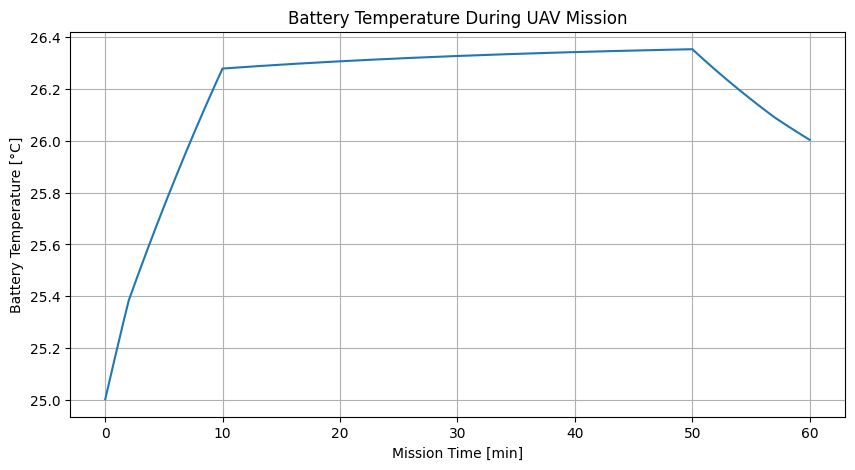

In [10]:
# ==============================
# BATTERY TEMPERATURE PLOT
# ==============================

import matplotlib.pyplot as plt

# Convert time from seconds to minutes
time_minutes = [t / 60 for t in time_history]

plt.figure(figsize=(10, 5))

plt.plot(time_minutes, temperature_history)

plt.xlabel("Mission Time [min]")
plt.ylabel("Battery Temperature [°C]")
plt.title("Battery Temperature During UAV Mission")

plt.grid(True)

plt.show()

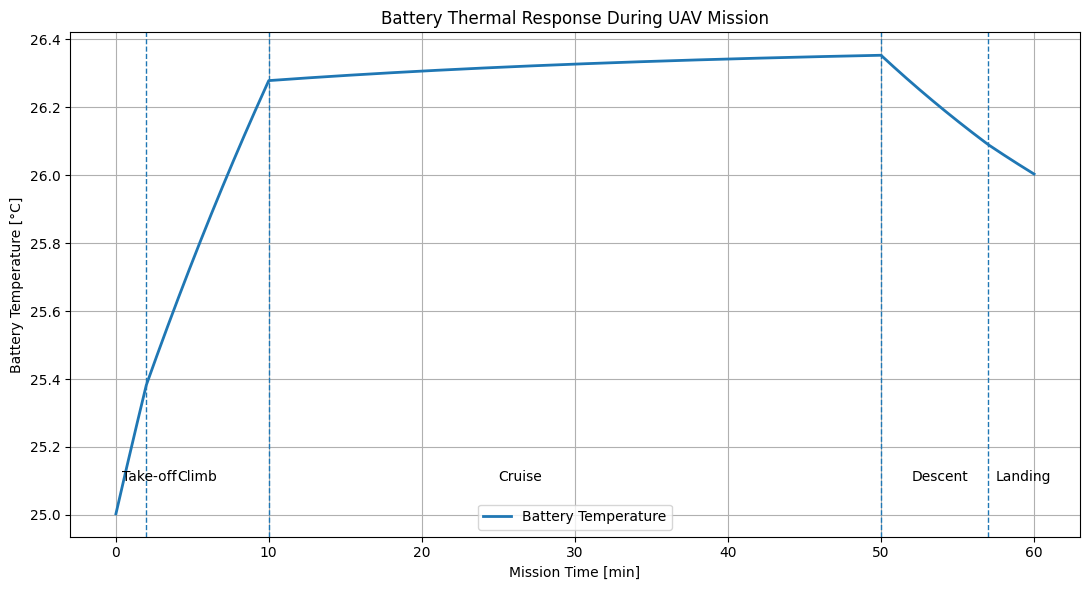

In [11]:
# ==============================
# PROFESSIONAL THERMAL PLOT
# ==============================

import matplotlib.pyplot as plt

time_minutes = [t / 60 for t in time_history]

plt.figure(figsize=(11, 6))

plt.plot(
    time_minutes,
    temperature_history,
    linewidth=2,
    label="Battery Temperature"
)

# Mission phase boundaries
phase_boundaries = [2, 10, 50, 57]

for boundary in phase_boundaries:
    plt.axvline(
        x=boundary,
        linestyle="--",
        linewidth=1
    )

# Phase labels
plt.text(0.4, 25.1, "Take-off")
plt.text(4, 25.1, "Climb")
plt.text(25, 25.1, "Cruise")
plt.text(52, 25.1, "Descent")
plt.text(57.5, 25.1, "Landing")

plt.xlabel("Mission Time [min]")
plt.ylabel("Battery Temperature [°C]")

plt.title(
    "Battery Thermal Response During UAV Mission"
)

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.show()

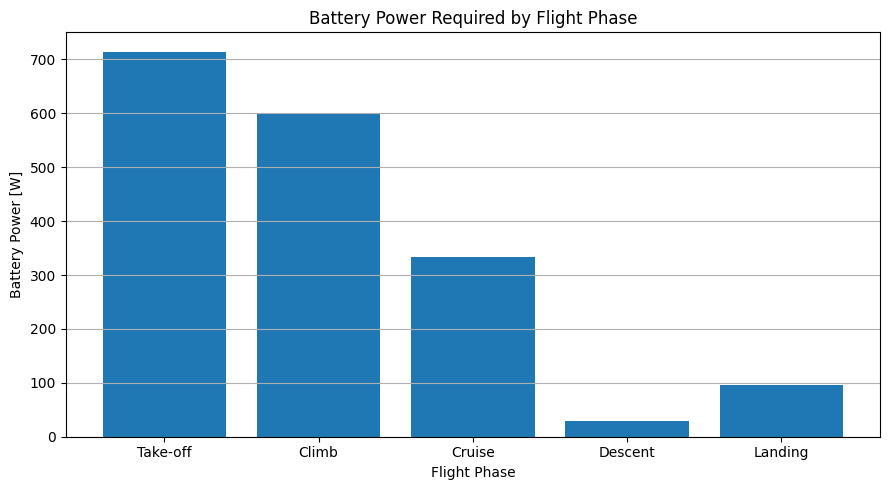

In [12]:
# ==============================
# BATTERY POWER BY FLIGHT PHASE
# ==============================

phase_names = []
battery_powers = []

for phase_name, data in mission.items():

    results = calculate_flight_phase(
        data["speed"],
        data["vertical_speed"],
        data["duration"]
    )

    cl, cd, drag, power_mech, power_batt, energy = results

    phase_names.append(phase_name)
    battery_powers.append(power_batt)

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(phase_names, battery_powers)

plt.xlabel("Flight Phase")
plt.ylabel("Battery Power [W]")
plt.title("Battery Power Required by Flight Phase")

plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [13]:
# ==============================
# BATTERY MASS ESTIMATION
# ==============================

# Assumed battery specific energy
battery_specific_energy = 200.0   # Wh/kg

# Original UAV data
original_total_mass = 12.0        # kg
original_battery_mass = 6.0       # kg

# UAV mass without battery
aircraft_mass_without_battery = (
    original_total_mass - original_battery_mass
)

# New battery mass based on required capacity
new_battery_mass = (
    required_battery_wh / battery_specific_energy
)

# New estimated UAV total mass
new_total_mass = (
    aircraft_mass_without_battery + new_battery_mass
)

print(
    "UAV mass without battery:",
    round(aircraft_mass_without_battery, 2),
    "kg"
)

print(
    "Estimated new battery mass:",
    round(new_battery_mass, 2),
    "kg"
)

print(
    "Estimated new UAV total mass:",
    round(new_total_mass, 2),
    "kg"
)

print(
    "Total mass reduction:",
    round(original_total_mass - new_total_mass, 2),
    "kg"
)

UAV mass without battery: 6.0 kg
Estimated new battery mass: 2.51 kg
Estimated new UAV total mass: 8.51 kg
Total mass reduction: 3.49 kg


In [14]:
# ==============================
# ORIGINAL VS LIGHTWEIGHT UAV
# ==============================

def mission_energy_for_mass(total_mass):

    local_weight = total_mass * gravity

    def phase_calculation(speed, vertical_speed, duration_min):

        cl = (2 * local_weight) / (
            air_density * speed**2 * wing_area
        )

        cd = cd0 + k * cl**2

        drag = (
            0.5
            * air_density
            * speed**2
            * wing_area
            * cd
        )

        power_drag = drag * speed

        power_vertical = local_weight * vertical_speed

        power_mechanical = power_drag + power_vertical

        power_mechanical = max(power_mechanical, 0)

        power_battery = power_mechanical / eta_total

        duration_h = duration_min / 60

        energy_wh = power_battery * duration_h

        return cl, cd, drag, power_battery, energy_wh

    total_energy_local = 0

    results_by_phase = {}

    for phase_name, data in mission.items():

        cl, cd, drag, power_batt, energy = phase_calculation(
            data["speed"],
            data["vertical_speed"],
            data["duration"]
        )

        total_energy_local += energy

        results_by_phase[phase_name] = {
            "CL": cl,
            "CD": cd,
            "Drag": drag,
            "Power": power_batt,
            "Energy": energy
        }

    return total_energy_local, results_by_phase


# Original UAV
energy_original, results_original = mission_energy_for_mass(
    original_total_mass
)

# Lightweight UAV
energy_light, results_light = mission_energy_for_mass(
    new_total_mass
)

# Difference
energy_saved = energy_original - energy_light

energy_saving_percent = (
    energy_saved / energy_original
) * 100

print("ORIGINAL UAV")
print("Mass:", round(original_total_mass, 2), "kg")
print("Mission energy:", round(energy_original, 2), "Wh")

print("\nLIGHTWEIGHT UAV")
print("Mass:", round(new_total_mass, 2), "kg")
print("Mission energy:", round(energy_light, 2), "Wh")

print("\nENERGY SAVING")
print("Energy saved:", round(energy_saved, 2), "Wh")
print("Energy saving:", round(energy_saving_percent, 2), "%")

ORIGINAL UAV
Mass: 12.0 kg
Mission energy: 334.46 Wh

LIGHTWEIGHT UAV
Mass: 8.51 kg
Mission energy: 293.5 Wh

ENERGY SAVING
Energy saved: 40.97 Wh
Energy saving: 12.25 %


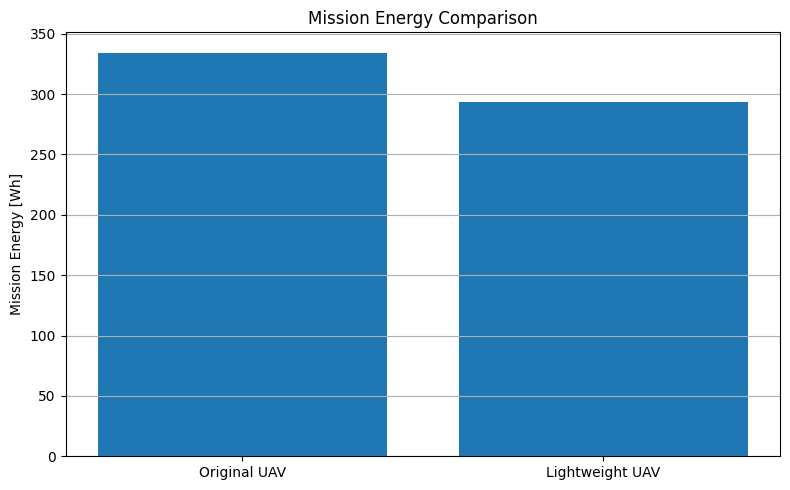

In [15]:
# ==============================
# ORIGINAL VS LIGHTWEIGHT PLOT
# ==============================

import matplotlib.pyplot as plt

labels = ["Original UAV", "Lightweight UAV"]
energies = [energy_original, energy_light]

plt.figure(figsize=(8, 5))

plt.bar(labels, energies)

plt.ylabel("Mission Energy [Wh]")
plt.title("Mission Energy Comparison")

plt.grid(axis="y")

plt.tight_layout()
plt.show()

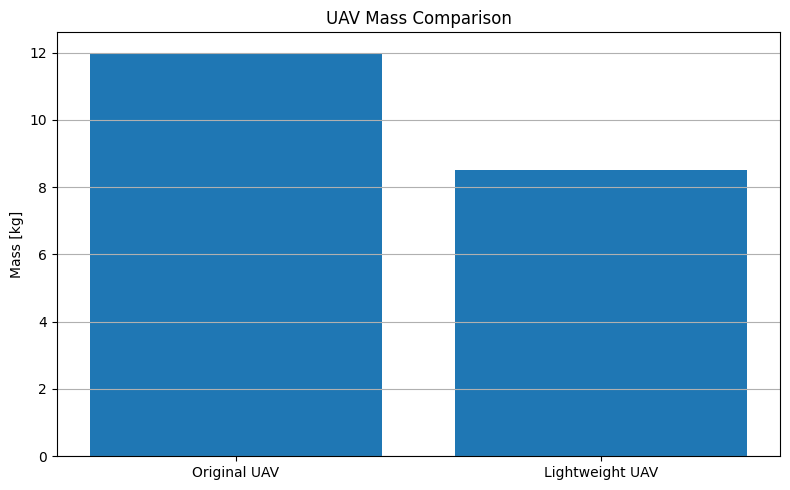

In [16]:
masses = [original_total_mass, new_total_mass]

plt.figure(figsize=(8, 5))

plt.bar(labels, masses)

plt.ylabel("Mass [kg]")
plt.title("UAV Mass Comparison")

plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [17]:
# ==============================
# WING SPAR - MATERIAL COMPARISON
# ==============================

# Spar geometry
spar_length = 2.8       # m
spar_width = 0.030      # m
spar_height = 0.050     # m
wall_thickness = 0.0015 # m

# Material densities
density_aluminum = 2700.0   # kg/m^3
density_cfrp = 1600.0       # kg/m^3

# Inner dimensions of the hollow spar
inner_width = spar_width - 2 * wall_thickness
inner_height = spar_height - 2 * wall_thickness

# Cross-sectional area
outer_area = spar_width * spar_height
inner_area = inner_width * inner_height

spar_material_area = outer_area - inner_area

# Spar volume
spar_volume = spar_material_area * spar_length

# Masses
spar_mass_aluminum = spar_volume * density_aluminum
spar_mass_cfrp = spar_volume * density_cfrp

# Mass saving
spar_mass_saved = spar_mass_aluminum - spar_mass_cfrp

saving_percent = (
    spar_mass_saved / spar_mass_aluminum
) * 100

print("Spar material volume:",
      round(spar_volume, 6), "m^3")

print("Aluminum spar mass:",
      round(spar_mass_aluminum, 3), "kg")

print("CFRP spar mass:",
      round(spar_mass_cfrp, 3), "kg")

print("Mass saved:",
      round(spar_mass_saved, 3), "kg")

print("Mass saving:",
      round(saving_percent, 2), "%")

Spar material volume: 0.000647 m^3
Aluminum spar mass: 1.746 kg
CFRP spar mass: 1.035 kg
Mass saved: 0.711 kg
Mass saving: 40.74 %


In [18]:
# ==============================
# SPAR BENDING ANALYSIS
# ==============================

# Lightweight UAV weight
lightweight_weight = new_total_mass * gravity

# Lift carried by one half-wing
lift_half_wing = lightweight_weight / 2

# Half-wing length
half_wing_length = wingspan / 2

# Resultant lift location for uniform load
resultant_distance = half_wing_length / 2

# Root bending moment
root_bending_moment = lift_half_wing * resultant_distance

# Second moment of area of hollow rectangular section
I_spar = (
    spar_width * spar_height**3
    - inner_width * inner_height**3
) / 12

# Distance from neutral axis to outer surface
y_max = spar_height / 2

# Maximum bending stress
bending_stress = (
    root_bending_moment * y_max / I_spar
)

# Convert Pa to MPa
bending_stress_mpa = bending_stress / 1e6

print("Lightweight UAV weight:",
      round(lightweight_weight, 2), "N")

print("Lift per half-wing:",
      round(lift_half_wing, 2), "N")

print("Root bending moment:",
      round(root_bending_moment, 2), "Nm")

print("Second moment of area:",
      I_spar, "m^4")

print("Maximum bending stress:",
      round(bending_stress_mpa, 2), "MPa")

Lightweight UAV weight: 83.47 N
Lift per half-wing: 41.73 N
Root bending moment: 31.3 Nm
Second moment of area: 7.889825000000007e-08 m^4
Maximum bending stress: 9.92 MPa


In [20]:
# ==============================
# SPAR DEFLECTION COMPARISON
# ==============================

# Half-wing length
half_span = wingspan / 2

# Equivalent lift force on one half-wing
half_wing_lift = new_total_mass * gravity / 2

# Young's modulus
E_aluminum = 69e9     # Pa
E_cfrp = 110e9        # Pa

# Tip deflection - simplified cantilever model
deflection_aluminum = (
    half_wing_lift * half_span**3
    / (3 * E_aluminum * I_spar)
)

deflection_cfrp = (
    half_wing_lift * half_span**3
    / (3 * E_cfrp * I_spar)
)

print(
    "Aluminum tip deflection:",
    round(deflection_aluminum * 1000, 2),
    "mm"
)

print(
    "CFRP tip deflection:",
    round(deflection_cfrp * 1000, 2),
    "mm"
)

Aluminum tip deflection: 8.62 mm
CFRP tip deflection: 5.41 mm


In [21]:
# ==============================
# FINAL CFRP OPTIMIZED UAV MASS
# ==============================

# Final UAV mass after CFRP spar substitution
final_uav_mass = new_total_mass - spar_mass_saved

# Recalculate mission energy
energy_final, results_final = mission_energy_for_mass(
    final_uav_mass
)

# Energy comparison
extra_energy_saved = energy_light - energy_final

extra_energy_saving_percent = (
    extra_energy_saved / energy_light
) * 100

total_energy_saved = energy_original - energy_final

total_energy_saving_percent = (
    total_energy_saved / energy_original
) * 100

print("BATTERY-OPTIMIZED UAV")
print("Mass:", round(new_total_mass, 2), "kg")
print("Mission energy:", round(energy_light, 2), "Wh")

print("\nBATTERY + CFRP OPTIMIZED UAV")
print("Mass:", round(final_uav_mass, 2), "kg")
print("Mission energy:", round(energy_final, 2), "Wh")

print("\nADDITIONAL CFRP BENEFIT")
print("Energy saved:", round(extra_energy_saved, 2), "Wh")
print("Energy saving:", round(extra_energy_saving_percent, 2), "%")

print("\nTOTAL IMPROVEMENT VS ORIGINAL")
print("Total energy saved:", round(total_energy_saved, 2), "Wh")
print("Total energy saving:", round(total_energy_saving_percent, 2), "%")

BATTERY-OPTIMIZED UAV
Mass: 8.51 kg
Mission energy: 293.5 Wh

BATTERY + CFRP OPTIMIZED UAV
Mass: 7.8 kg
Mission energy: 286.53 Wh

ADDITIONAL CFRP BENEFIT
Energy saved: 6.97 Wh
Energy saving: 2.37 %

TOTAL IMPROVEMENT VS ORIGINAL
Total energy saved: 47.93 Wh
Total energy saving: 14.33 %


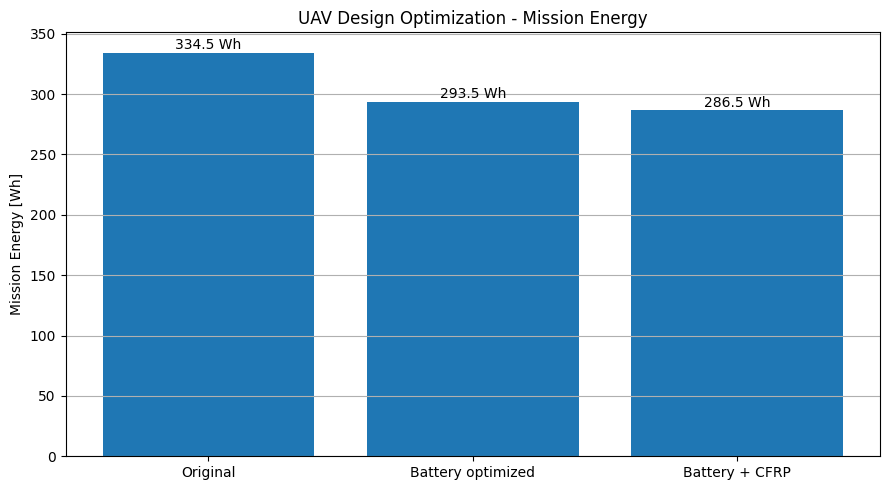

In [22]:
# ==============================
# FINAL DESIGN COMPARISON
# ==============================

import matplotlib.pyplot as plt

configurations = [
    "Original",
    "Battery optimized",
    "Battery + CFRP"
]

mission_energies = [
    energy_original,
    energy_light,
    energy_final
]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    configurations,
    mission_energies
)

plt.ylabel("Mission Energy [Wh]")
plt.title("UAV Design Optimization - Mission Energy")

plt.grid(axis="y")

for bar, value in zip(bars, mission_energies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 3,
        f"{value:.1f} Wh",
        ha="center"
    )

plt.tight_layout()
plt.show()

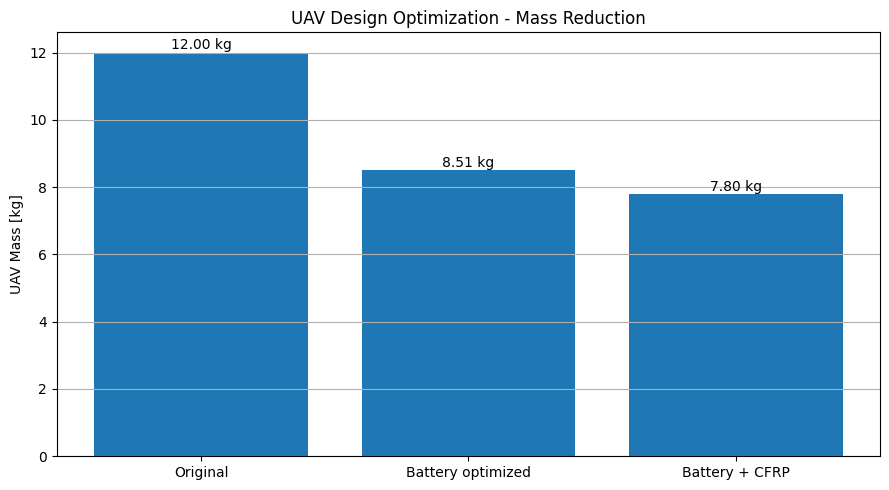

In [23]:
# ==============================
# MASS COMPARISON
# ==============================

masses = [
    original_total_mass,
    new_total_mass,
    final_uav_mass
]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    configurations,
    masses
)

plt.ylabel("UAV Mass [kg]")
plt.title("UAV Design Optimization - Mass Reduction")

plt.grid(axis="y")

for bar, value in zip(bars, masses):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f"{value:.2f} kg",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [24]:
# ==============================
# FINAL RESULTS TABLE
# ==============================

import pandas as pd

final_results = pd.DataFrame({
    "Configuration": [
        "Original UAV",
        "Battery Optimized",
        "Battery + CFRP Optimized"
    ],

    "Mass_kg": [
        original_total_mass,
        new_total_mass,
        final_uav_mass
    ],

    "Mission_Energy_Wh": [
        energy_original,
        energy_light,
        energy_final
    ],

    "Energy_Saving_percent": [
        0,
        (energy_original - energy_light) / energy_original * 100,
        (energy_original - energy_final) / energy_original * 100
    ]
})

print(final_results)

              Configuration    Mass_kg  Mission_Energy_Wh  \
0              Original UAV  12.000000         334.461882   
1         Battery Optimized   8.508464         293.495625   
2  Battery + CFRP Optimized   7.796984         286.528425   

   Energy_Saving_percent  
0               0.000000  
1              12.248408  
2              14.331516  


In [25]:
# Export results to CSV
final_results.to_csv(
    "UAV_Final_Results.csv",
    index=False
)

print("CSV file created successfully.")

CSV file created successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')